# Cross-topology transfer of factorized graph Koopman operators

This notebook measures **zero-shot** rollout when a `koopman="graph"` model
is trained on a path graph with $N_1$ nodes and evaluated on a path with
$N_2 \neq N_1$, against an in-distribution holdout and a `koopman="pernode"`
control. You will see that transfer need not fail catastrophically on this
surrogate — and that it does **not** demonstrate a transfer advantage over
per-node dynamics.


## Setup


In [1]:
import warnings

from tqdm.std import TqdmExperimentalWarning, TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import torch

import koopman_graph
from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.datasets.synthetic import SyntheticDynamicGraphBenchmark

SEED = 0
N1, N2 = 4, 6
FEATURES = 2
LATENT = 4
STEPS = 8
# Match the seeded regression recipe in tests/test_cross_topology.py (epochs=100).
EPOCHS = 100
LR = 5e-3
torch.manual_seed(SEED)

DIFFUSION = dict(
    in_channels=FEATURES,
    topology="path",
    diffusion_rate=0.35,
    decay_rate=0.92,
    noise_std=0.0,
    initial_state="ones",
)


def make_model(koopman: str, **kwargs) -> GraphKoopmanModel:
    return GraphKoopmanModel(
        GNNEncoder(FEATURES, 32, LATENT, num_layers=2),
        GNNDecoder(LATENT, 32, FEATURES, num_layers=2),
        latent_dim=LATENT,
        time_step=1.0,
        koopman=koopman,
        **kwargs,
    )


def rollout_mse(model: GraphKoopmanModel, sequence, *, steps: int = STEPS) -> float:
    preds = model.predict(sequence[0], steps)
    errors = []
    for h in range(steps):
        pred, target = preds[h].x, sequence[h + 1].x
        assert pred is not None and target is not None
        errors.append(torch.mean((pred - target) ** 2))
    return float(torch.stack(errors).mean().item())


print(f"koopman_graph {koopman_graph.__version__}")
print(f"torch {torch.__version__}")


koopman_graph 0.10.0
torch 2.13.0


## Motivation and background

Compositional / factorized graph Koopman models couple each node to its
neighbors through shared self and neighbor blocks
([Li et al., 2020](https://openreview.net/forum?id=H1ldzA4tPr)). A natural
hope is that, because the operator is written in terms of the adjacency rather
than a fixed $N \times N$ joint map, a model trained on one graph size can
roll out on another without retraining.

What this package already had was weaker evidence: topology *ablation* at fixed
$N$ (notebook 09) and mid-horizon *rewiring* with an oracle
`future_topologies` schedule (notebook 18). Neither is zero-shot transfer across
node counts. Here we measure the zero-shot case on a small seeded diffusion
surrogate and compare against `koopman="pernode"`, which ignores topology at
advance time.

**Citation note.** Li et al. (2020) motivate the factorized self/neighbor
construction. This notebook does **not** claim to reproduce their transfer
results; it reports what *this* package does on *this* surrogate.


## Minimal example: train on $N_1$, predict on $N_2$

Generate path-diffusion sequences with identical dynamics parameters, train a
graph operator on $N_1 = 4$, and roll out on $N_2 = 6$. The only requirement
is that encoder/decoder feature widths match; node count is not baked into the
factorized operator.


In [2]:
train = SyntheticDynamicGraphBenchmark.generate(
    num_nodes=N1, num_timesteps=50, seed=0, **DIFFUSION
)
hold_n1 = SyntheticDynamicGraphBenchmark.generate(
    num_nodes=N1, num_timesteps=20, seed=1, **DIFFUSION
)
hold_n2 = SyntheticDynamicGraphBenchmark.generate(
    num_nodes=N2, num_timesteps=20, seed=2, **DIFFUSION
)

torch.manual_seed(SEED)
graph_model = make_model("graph")
_ = graph_model.fit(train, epochs=EPOCHS, lr=LR, device="cpu")

preds_n2 = graph_model.predict(hold_n2[0], steps=STEPS)
assert preds_n2[-1].x is not None
assert preds_n2[-1].x.shape == (N2, FEATURES)

mse_in = rollout_mse(graph_model, hold_n1)
mse_xfer = rollout_mse(graph_model, hold_n2)
print(f"graph in-distribution MSE ({N1} nodes): {mse_in:.4f}")
print(f"graph zero-shot transfer MSE ({N2} nodes): {mse_xfer:.4f}")
print(f"relative gap |xfer - in| / in: {abs(mse_xfer - mse_in) / max(mse_in, 1e-8):.3f}")


graph in-distribution MSE (4 nodes): 0.2611
graph zero-shot transfer MSE (6 nodes): 0.2594
relative gap |xfer - in| / in: 0.006


## Progressive deep dive: per-node control and hard boundaries

### Per-node control

`koopman="pernode"` advances each node's latent independently of
`edge_index`. It is the correct control for "does factorization help
transfer?" — not `koopman_parameterization="dense"`, which only chooses how
the Koopman matrix is stored.


In [3]:
metrics = {}
for kind in ("graph", "pernode"):
    torch.manual_seed(SEED)
    model = make_model(kind)
    model.fit(train, epochs=EPOCHS, lr=LR, device="cpu")
    metrics[kind] = {
        "in_dist": rollout_mse(model, hold_n1),
        "transfer": rollout_mse(model, hold_n2),
    }

for kind, vals in metrics.items():
    print(
        f"{kind:8s}  in-dist={vals['in_dist']:.4f}  "
        f"transfer={vals['transfer']:.4f}"
    )


graph     in-dist=0.2611  transfer=0.2594
pernode   in-dist=0.2077  transfer=0.2061


### Configurations that *cannot* transfer across $N$

Two supported features bind node cardinality and raise on a change:
`learn_topology="self_adaptive"` (static `AdaptiveAdjacency` per fit) and an
explicit `koopman_orbit_partition` sized for $N_1$. Exclude these when the
evaluation graph has a different node count.


In [4]:
adaptive = make_model("graph", learn_topology="self_adaptive")
adaptive.fit(train, epochs=2, lr=LR, device="cpu")
try:
    adaptive.predict(hold_n2[0], steps=2)
    print("adaptive: unexpected success")
except ValueError as exc:
    print(f"adaptive on N2: {exc}")

orbit = make_model("graph", koopman_orbit_partition=((0, 1), (2, 3)))
orbit.fit(train, epochs=2, lr=LR, device="cpu")
try:
    orbit.predict(hold_n2[0], steps=2)
    print("orbit: unexpected success")
except ValueError as exc:
    print(f"orbit on N2: {exc}")


adaptive on N2: AdaptiveAdjacency is static per fit: num_nodes was 4, got 6. Rebuild the model for a different graph size
orbit on N2: orbit partition was bound for 4 nodes, got num_nodes=6


## Results

Bar comparison of mean multi-step MSE. Look for two things: (1) whether
transfer (hatched) stays near in-distribution (solid) for `graph`, and
(2) whether `graph` transfer undercuts `pernode` transfer. On this seeded
path-diffusion surrogate (same recipe as the regression test: 100 epochs),
transfer tracks in-distribution for both kinds, and absolute MSE for
`pernode` is lower than for `graph` — so factorization does not win on
error here.


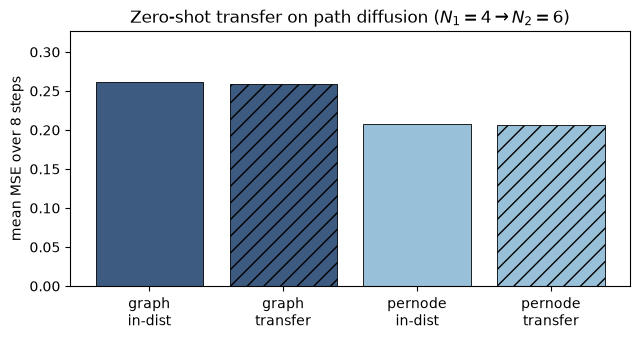

In [5]:
labels = ["graph\nin-dist", "graph\ntransfer", "pernode\nin-dist", "pernode\ntransfer"]
values = [
    metrics["graph"]["in_dist"],
    metrics["graph"]["transfer"],
    metrics["pernode"]["in_dist"],
    metrics["pernode"]["transfer"],
]
colors = ["#3d5a80", "#3d5a80", "#98c1d9", "#98c1d9"]
hatches = ["", "//", "", "//"]

fig, ax = plt.subplots(figsize=(6.5, 3.5))
bars = ax.bar(labels, values, color=colors, edgecolor="black", linewidth=0.6)
for bar, hatch in zip(bars, hatches, strict=True):
    bar.set_hatch(hatch)
ax.set_ylabel(f"mean MSE over {STEPS} steps")
ax.set_title(
    rf"Zero-shot transfer on path diffusion ($N_1 = {N1} \rightarrow N_2 = {N2}$)"
)
ax.set_ylim(0, max(values) * 1.25)
fig.tight_layout()
plt.show()


## Interpretation / discussion

On this Laplacian-diffusion path graph with matched dynamics parameters,
factorized `koopman="graph"` **runs** at $N_2 \neq N_1$ without shape errors,
and transfer MSE stays close to the in-distribution holdout. That is evidence
against a hard size lock-in for the default graph operator path.

It is **not** evidence of a transfer *advantage*. On this seeded recipe the
per-node control achieves lower absolute multi-step MSE on both the
in-distribution and transfer holdouts (while matching the same
transfer-versus-in-distribution pattern). The diffusion surrogate is also
structurally similar across path lengths, so success should not be extrapolated
to traffic networks, epidemics with source asymmetry, or systems where the
right coupling depends strongly on $N$.

Adaptive topology learning and orbit ties remain $N$-bound by design; treat
those as separate contracts, not as failures of factorization.


## Takeaways

- Use `koopman="graph"` when neighbor coupling is part of the model; node count
  need not match training for the default (non-adaptive, non-orbit) path.
- Compare transfer claims against `koopman="pernode"`, not against a missing
  baseline — on this surrogate, factorization transfers
  (transfer $\approx$ in-dist) without beating per-node on absolute MSE.
- Do **not** combine cross-$N$ evaluation with `learn_topology="self_adaptive"`
  or an orbit partition built for $N_1$; both raise clear errors.
- Treat Li et al. (2020) as motivation for the operator form; do not read this
  notebook as a reproduction of their zero-shot transfer results.


## Further reading

- Package API: `GraphKoopmanModel`, `koopman="graph"` / `"pernode"`
  ([docs](https://koopmangraph.readthedocs.io/))
- Related notebooks: `09_topology_ablation.ipynb` (fixed-$N$ ablation),
  `18_dynamic_topology.ipynb` (oracle `future_topologies`),
  `35_symmetry_adapted_operator.ipynb` (orbit ties)
- Li, Y., He, H., Wu, J., Katabi, D., & Torralba, A. (2020). Learning
  compositional Koopman operators for model-based control.
  In *International Conference on Learning Representations (ICLR)*.
  https://openreview.net/forum?id=H1ldzA4tPr
  (also arXiv:1910.08264)
